# NOTEBOOK #03 — Análisis Exploratorio de Datos (EDA)

**Proyecto Integrador — Minería de Datos I — Tec. Sup. Ciencia de Datos — ITSE**  
**Integrantes:** Daniela Fernandez — Julio Nahuel Gomez  
**Profesor:** Fernando Elias Mubarqui  
**Año:** 2026

**Dataset:** Usuarios de plataforma de streaming (dataset limpio)  
**Objetivo:** Realizar un análisis exploratorio univariado, bivariado y multivariado del dataset ya limpio, con interpretaciones vinculadas a los objetivos del proyecto.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/streaming_users_clean.csv')

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 7414 filas, 8 columnas


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
1,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
2,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
3,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1
4,10005,20,Básico,670.2,Uruguay,Drama,2020-07-03,2


## ANÁLISIS UNIVARIADO

El análisis univariado estudia cada variable de forma independiente para comprender su distribución y comportamiento.

### Visualización 1 — ¿Cómo se distribuyen los usuarios por plan de suscripción?

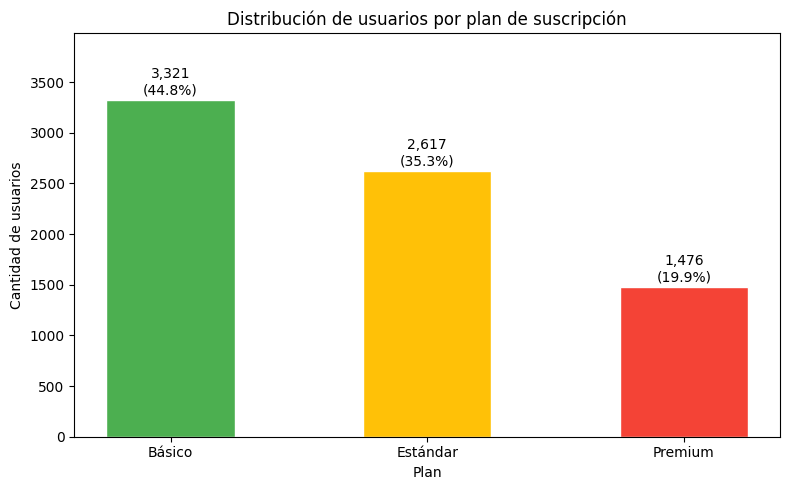

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

conteo = df['subscription_plan'].value_counts()
colores = ['#4CAF50', '#FFC107', '#F44336']

bars = ax.bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.5)

for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Distribución de usuarios por plan de suscripción')
ax.set_xlabel('Plan')
ax.set_ylabel('Cantidad de usuarios')
ax.set_ylim(0, conteo.max() * 1.2)

plt.tight_layout()
plt.savefig('../reports/viz1_univariado_planes.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** El plan Básico concentra la mayor parte de los usuarios, seguido por Estándar y luego Premium. Esto indica que la mayoría de los usuarios opta por el plan de menor costo. El plan Premium tiene la menor adopción, lo que es esperable en servicios de streaming donde los planes más caros tienen menor cantidad de suscriptores.

### Visualización 2 — ¿Cómo es la distribución de edades de los usuarios?

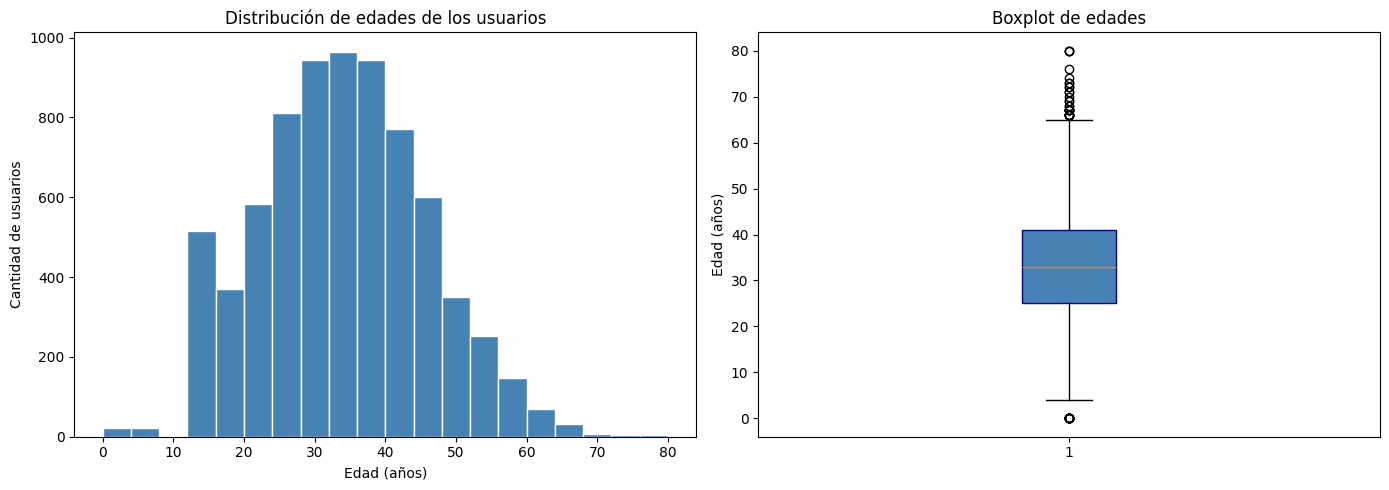

Media: 33.5 años
Mediana: 33.0 años
Mínimo: 0 años
Máximo: 80 años
Desvío estándar: 11.8 años


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de edades de los usuarios')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Cantidad de usuarios')

axes[1].boxplot(df['age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot de edades')
axes[1].set_ylabel('Edad (años)')

plt.tight_layout()
plt.savefig('../reports/viz2_univariado_edad.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Media: {df['age'].mean():.1f} años")
print(f"Mediana: {df['age'].median():.1f} años")
print(f"Mínimo: {df['age'].min()} años")
print(f"Máximo: {df['age'].max()} años")
print(f"Desvío estándar: {df['age'].std():.1f} años")

**Interpretación:** La distribución de edades es aproximadamente uniforme, lo que indica que la plataforma tiene usuarios de todas las edades sin una concentración marcada en un grupo etario particular. La mediana y la media están cercanas entre sí, lo que confirma una distribución bastante simétrica. Esto sugiere que el servicio de streaming no está orientado exclusivamente a un segmento etario específico.

## ANÁLISIS BIVARIADO

Estudiamos la relación entre dos variables para identificar patrones y asociaciones.

### Visualización 3 — ¿Los usuarios con plan Premium ven más contenido que los de otros planes?

C:\Users\danie\AppData\Local\Temp\ipykernel_6084\1372854541.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=orden, patch_artist=True)


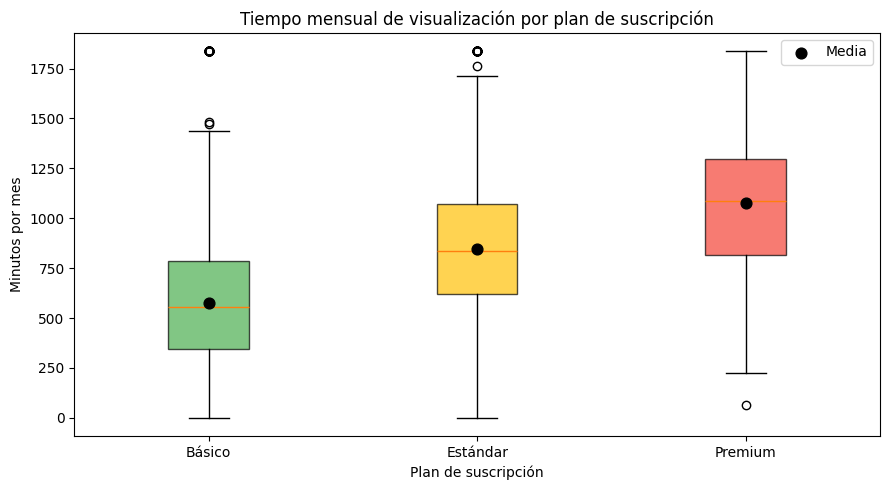

Estadísticos por plan:
                     mean  median    std
subscription_plan                       
Básico              577.7   555.8  340.9
Estándar            847.2   835.7  331.1
Premium            1076.2  1085.7  307.8


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

orden = ['Básico', 'Estándar', 'Premium']
colores = ['#4CAF50', '#FFC107', '#F44336']

data_plot = [df[df['subscription_plan'] == plan]['monthly_watch_time_mins'].dropna()
             for plan in orden]

bp = ax.boxplot(data_plot, labels=orden, patch_artist=True)

for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, (plan, color) in enumerate(zip(orden, colores), start=1):
    media = df[df['subscription_plan'] == plan]['monthly_watch_time_mins'].mean()
    ax.scatter(i, media, color='black', zorder=5, s=60, label='Media' if i == 1 else '')

ax.set_title('Tiempo mensual de visualización por plan de suscripción')
ax.set_xlabel('Plan de suscripción')
ax.set_ylabel('Minutos por mes')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/viz3_bivariado_plan_watchtime.png', dpi=150, bbox_inches='tight')
plt.show()

print("Estadísticos por plan:")
print(df.groupby('subscription_plan')['monthly_watch_time_mins'].agg(['mean', 'median', 'std']).round(1))

**Interpretación:** Los usuarios con plan Premium muestran un tiempo de visualización mensual mayor que los de planes Básico y Estándar, tanto en mediana como en media. Esto sugiere que existe una relación entre el tipo de plan contratado y el nivel de consumo: los usuarios que más usan la plataforma tienden a optar por planes superiores, o bien el acceso a más contenido que ofrece el plan Premium incentiva un mayor consumo.

### Visualización 4 — ¿Cuál es el género favorito según el país?

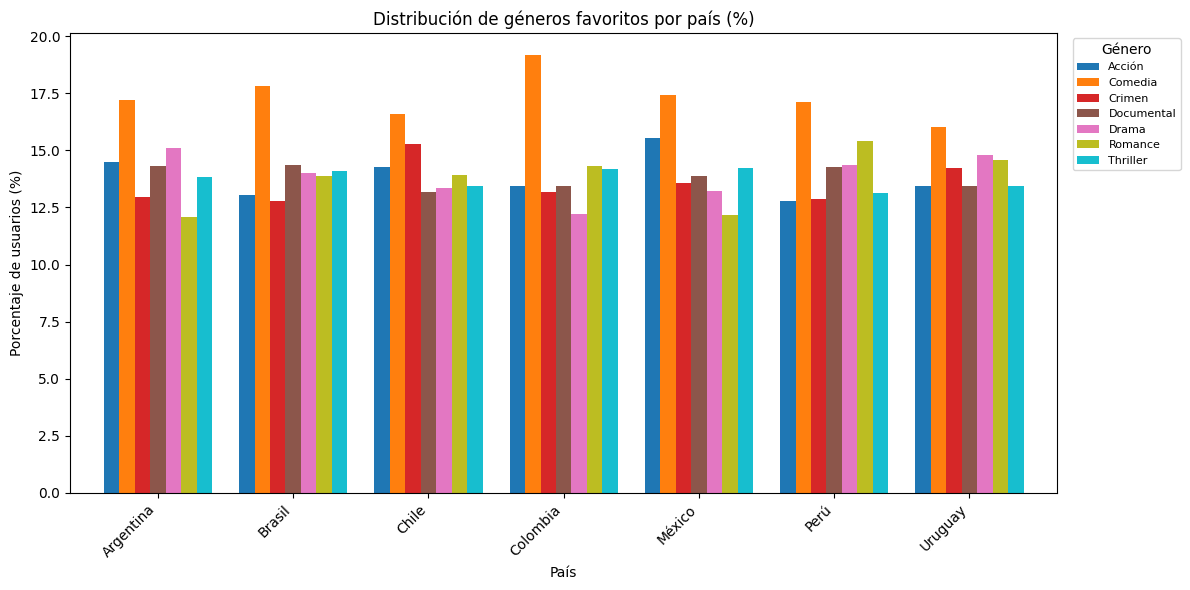

In [13]:
tabla = df.groupby(['country', 'favorite_genre']).size().unstack(fill_value=0)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))

tabla_pct.plot(kind='bar', ax=ax, colormap='tab10', width=0.8)

ax.set_title('Distribución de géneros favoritos por país (%)')
ax.set_xlabel('País')
ax.set_ylabel('Porcentaje de usuarios (%)')
ax.legend(title='Género', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../reports/viz4_bivariado_genero_pais.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** La distribución de géneros favoritos es relativamente homogénea entre países, sin diferencias drásticas. Sin embargo se observan algunas variaciones: ciertos países muestran mayor preferencia por géneros como Drama o Acción respecto a otros. Esto indica que si bien el comportamiento general es similar entre regiones, existen matices que podrían considerarse para personalizar recomendaciones por país.

## ANÁLISIS MULTIVARIADO

Estudiamos la relación entre tres o más variables simultáneamente.

### Visualización 5 — ¿La edad y el tiempo de visualización varían según el plan de suscripción?

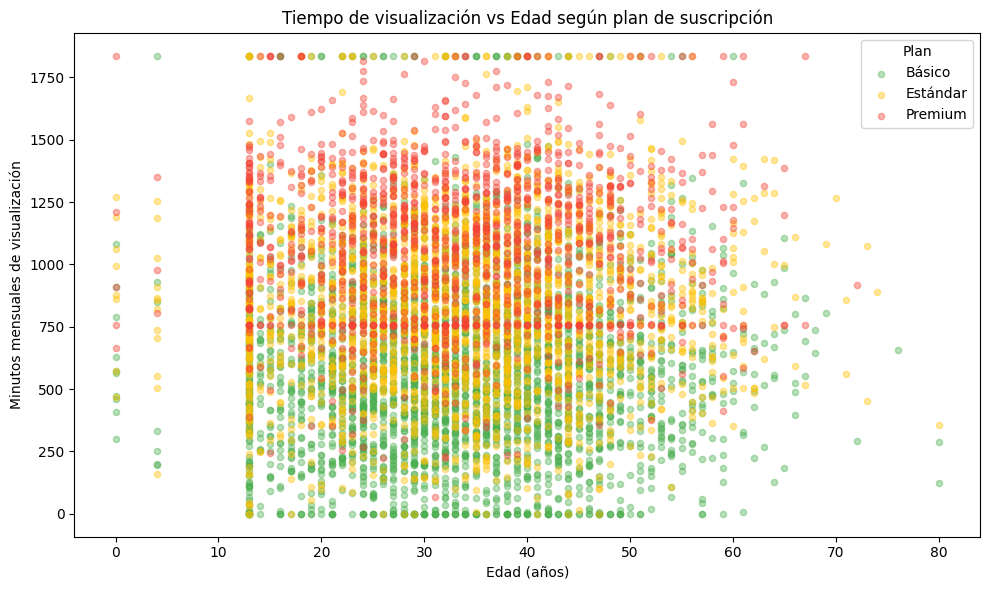

Correlación entre edad y tiempo de visualización: 0.006


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

colores_plan = {'Básico': '#4CAF50', 'Estándar': '#FFC107', 'Premium': '#F44336'}

for plan, color in colores_plan.items():
    subset = df[df['subscription_plan'] == plan]
    ax.scatter(subset['age'], subset['monthly_watch_time_mins'],
               c=color, label=plan, alpha=0.4, s=20)

ax.set_title('Tiempo de visualización vs Edad según plan de suscripción')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Minutos mensuales de visualización')
ax.legend(title='Plan')

plt.tight_layout()
plt.savefig('../reports/viz5_multivariado_edad_watchtime_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlación entre edad y tiempo de visualización: {df['age'].corr(df['monthly_watch_time_mins']):.3f}")

**Interpretación:** El gráfico muestra que no existe una correlación lineal fuerte entre la edad y el tiempo de visualización. Los usuarios de todas las edades presentan niveles de consumo similares. Sin embargo al separar por plan de suscripción, los usuarios Premium tienden a concentrarse en niveles de consumo más altos independientemente de la edad, lo que refuerza la relación entre plan y consumo identificada en la visualización anterior.

## RESUMEN DEL ANÁLISIS EXPLORATORIO

A partir del análisis realizado identificamos los siguientes hallazgos principales:

- El plan Básico es el más adoptado, concentrando la mayor parte de los usuarios de la plataforma.
- La distribución de edades es aproximadamente uniforme, sin concentración en un grupo etario particular.
- Los usuarios con plan Premium muestran mayor tiempo de visualización mensual que los de planes inferiores.
- La preferencia de género es relativamente homogénea entre países, con pequeñas variaciones culturales.
- No existe correlación lineal fuerte entre edad y tiempo de visualización, pero el plan de suscripción sí muestra diferencias claras en el nivel de consumo.